# Who Are the Main Characters in the Gospel of John? 👤

The Gospel of John is known for its intimate conversations and long dialogues. But who is Jesus actually talking to? Who are the main characters that move the story forward?

In this notebook, we analyze the text of John to automatically count every time a specific person is mentioned. This helps us objectively see who the "main characters" are, right down to the numbers!

We will:
1. Load a pre-analyzed dataset (TAGNT) which already has every Greek word tagged with a unique "Strong's Number" (a standard way of identifying biblical words).
2. Cross-reference those numbers against a database of biblical people (STEPBible) to find their English names.
3. Show a clear, top-20 bar chart of the most frequently mentioned people.

In [1]:
import json
import collections
import re
import pandas as pd
import matplotlib.pyplot as plt

# Load people.json to get a set of person names and their dStrongs
print("Loading STEPBible people database...")
people_file = 'data/NT/Proper_Nouns/people.json'
with open(people_file, 'r', encoding='utf-8') as f:
    # Skip comment lines at the beginning
    lines = f.readlines()
    json_lines = [line for line in lines if not line.strip().startswith('//')]
    people_data = json.loads(''.join(json_lines))

# We want to map strongs to Person Names
strongs_to_person = {}
for key, data in people_data.items():
    # get the base name (before @)
    name = key.split('@')[0]
    for dStrong in data.get('allDStrongs', []):
        strongs_to_person[dStrong] = name

print(f"Loaded {len(strongs_to_person)} Strongs mappings for people.")

Loading STEPBible people database...
Loaded 3710 Strongs mappings for people.


## 1. Counting the Names

Now we parse the Tyndale Amalgamated Greek New Testament (TAGNT) file. This dataset is fantastic because scholars have already gone through and assigned a "Strong's Number" to every single word. 

We simply look for numbers starting with 'G' (for Greek) that match the numbers in our people database, and count them up!

In [2]:
# Now parse the TAGNT file for John
tagnt_file = 'STEPBible-Data/Translators Amalgamated OT+NT/TAGNT Mat-Jhn - Translators Amalgamated Greek NT - STEPBible.org CC-BY.txt'

john_person_freq = collections.Counter()

print("Analyzing the Gospel of John...")
with open(tagnt_file, 'r', encoding='utf-8') as f:
    for line in f:
        if not line.startswith('Jhn.'):
            continue
            
        parts = line.strip().split('\t')
        if len(parts) > 7:
            # Typical format:
            # Ref | WordType | Greek | Lexicon | Parsing | Strongs | English
            # Let's extract Strongs, usually around index 6 or 7.
            # We can just look for G followed by digits.
            strongs_matches = re.findall(r'G\d{4}[A-Za-z]?', line)
            for s in strongs_matches:
                if s in strongs_to_person:
                    person_name = strongs_to_person[s]
                    john_person_freq[person_name] += 1
                    # only count each strongs once per word line
                    break

# Convert our list to a pandas DataFrame for easy sorting and plotting
names_data = [{"Name": name.replace("_", " "), "Frequency": freq} for name, freq in john_person_freq.items()]
df_names = pd.DataFrame(names_data)
df_names = df_names.sort_values(by="Frequency", ascending=False).reset_index(drop=True)

print("Top 5 Most Mentioned Names:")
print(df_names.head())

Analyzing the Gospel of John...
Top 5 Most Mentioned Names:
     Name  Frequency
0   Jesus        253
1   Judah        133
2   Peter         57
3  Pilate         40
4    John         24


## 2. Visualizing the Top 20 Characters

Let's build a bar chart to easily see the most dominant figures in John's narrative. 
*Spoiler alert: Like all the Gospels, it is heavily centered on Jesus! But notice how prominent Peter and Pilate are compared to the others.*

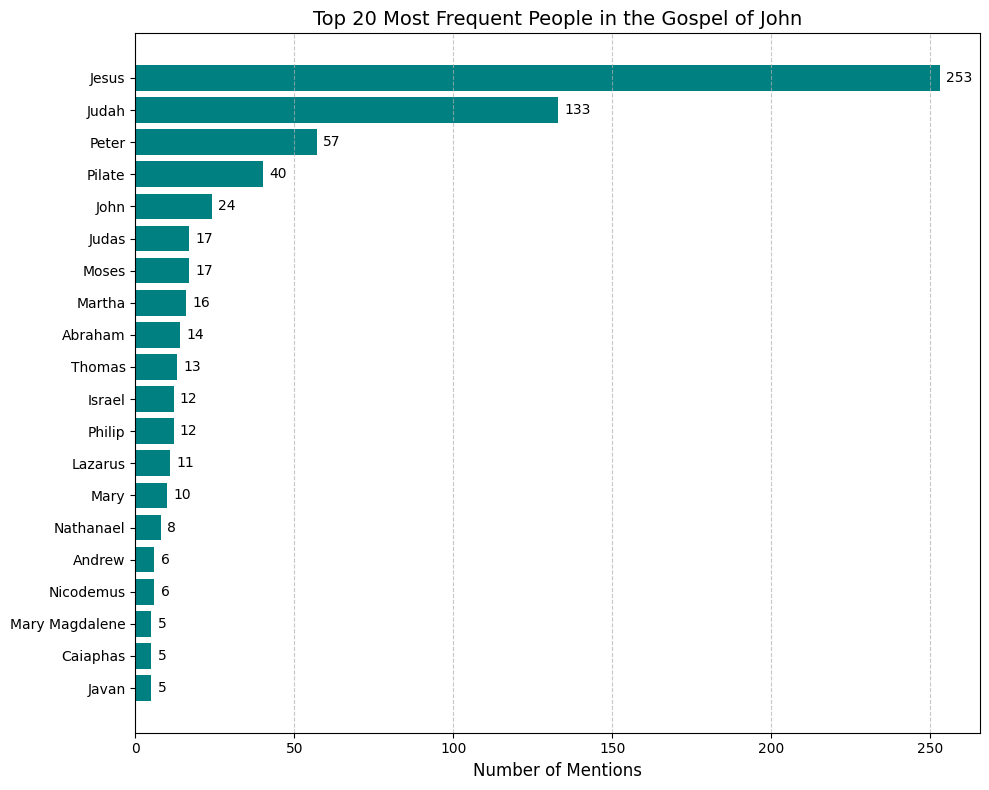

In [3]:
# Take the top 20 most frequent names
top_20 = df_names.head(20).copy()

# Reverse the order so the highest frequency is at the top of the horizontal bar chart
top_20 = top_20.iloc[::-1]

plt.figure(figsize=(10, 8))
# Using a nice teal color to match the styling
plt.barh(top_20["Name"], top_20["Frequency"], color="teal")
plt.xlabel("Number of Mentions", fontsize=12)
plt.title("Top 20 Most Frequent People in the Gospel of John", fontsize=14)
plt.grid(axis='x', linestyle='--', alpha=0.7)

# Add the exact numbers to the end of the bars
for index, value in enumerate(top_20["Frequency"]):
    plt.text(value + 2, index, str(value), va='center', fontsize=10)

plt.tight_layout()
plt.show()